# 04c - Reprezentacja wewnętrzna a podatność klas

Praca magisterska: *„Analiza wpływu zakłóceń i perturbacji obrazów na stabilność reprezentacji generowanych przez głębokie sieci neuronowe, z uwzględnieniem klas obiektów"*

---

## 1. Konfiguracja i zależności

Import bibliotek, wagi modeli, ścieżki katalogów.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models

from datasets import load_dataset, VerificationMode

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

from statsmodels.stats.multitest import multipletests
from skimage import filters as _sk_filters

import sys, importlib, glob
from huggingface_hub import login

!pip install imagecorruptions --quiet
from imagecorruptions import corrupt
import imagecorruptions as _ic

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 170)
plt.rcParams['figure.dpi'] = 110

ROOT         = '/content/drive/MyDrive/mgr_266484'
DATA_DIR     = f'{ROOT}/data'
RESULTS_DIR  = f'{ROOT}/corrupted'
ANALYSIS_DIR = f'{ROOT}/analysis'
FIGURES_DIR  = f'{ROOT}/figures'
EMB_DIR      = f'{ROOT}/embeddings'

for d in (ANALYSIS_DIR, FIGURES_DIR, EMB_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Urządzenie:', DEVICE)

login()

MODEL_REGISTRY = {
    'resnet50':  ('CNN', '#a9cce3'),
    'resnet101': ('CNN', '#7fb3d5'),
    'resnet152': ('CNN', '#5499c7'),
    'vit_b_32':  ('ViT', '#f6c9a0'),
    'vit_b_16':  ('ViT', '#f0ad7c'),
}

FRAGILE_C, ROBUST_C, OTHER_C = '#A83232', '#27506E', '#D7DBE0'
CNN_C, VIT_C, ACCENT = '#5499c7', '#e59866', '#3a4a5a'

SHARED_FRAC      = 0.20
MIN_CLEAN_ROBUST = 0.70
IMGS_PER_CLASS   = 50

def model_family(name):
    return MODEL_REGISTRY.get(name, ('inny', None))[0]

def tidy(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=3, color='#444')

def save_fig(fig, name, dpi=300):
    fig.savefig(f'{FIGURES_DIR}/{name}.pdf', bbox_inches='tight')
    fig.savefig(f'{FIGURES_DIR}/{name}.png', dpi=dpi, bbox_inches='tight')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.4 MB/s eta 0:00:00
Urządzenie: cpu


## 2. Wczytanie tabeli

In [ ]:
CT_PATH = f'{ANALYSIS_DIR}/class_robustness.csv'

CT = pd.read_csv(CT_PATH)
MODELS = sorted(m for m in CT.model.unique() if m != 'vit_l_16')
CT = CT[CT.model.isin(MODELS)]
print('Modele:', MODELS)
print('Wierszy w CT:', len(CT))

thr          = {m: CT[CT.model == m].rel_drop.quantile(1 - SHARED_FRAC) for m in MODELS}
fragile_sets = {m: set(CT[(CT.model == m) & (CT.rel_drop >= thr[m])].wnid) for m in MODELS}

_robust_base = {m: CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)] for m in MODELS}
robust_thr   = {m: _robust_base[m].rel_drop.quantile(SHARED_FRAC) for m in MODELS}
robust_sets  = {m: set(_robust_base[m][_robust_base[m].rel_drop <= robust_thr[m]].wnid) for m in MODELS}

shared_fragile = set.intersection(*fragile_sets.values()) if fragile_sets else set()
shared_robust  = set.intersection(*robust_sets.values())  if robust_sets  else set()
print(f'Wspólnie podatne: {len(shared_fragile)}  |  wspólnie odporne: {len(shared_robust)}')

TARGET_WNIDS = sorted(CT.wnid.unique())
print('Klas do policzenia embeddingów:', len(TARGET_WNIDS))

Modele: ['resnet101', 'resnet152', 'resnet50', 'vit_b_16', 'vit_b_32']
Wierszy w CT: 5000
Wspólnie podatne: 99  |  wspólnie odporne: 94
Klas do policzenia embeddingów: 1000


## 3. Wczytanie obrazów walidacyjnych

In [ ]:
def to_uint8_224(pil_img):
    img = pil_img.convert('RGB'); w, h = img.size; s = 256
    img = img.resize((s, int(s * h / w)) if w < h else (int(s * w / h), s), Image.BILINEAR)
    w2, h2 = img.size
    img = img.crop(((w2 - 224) // 2, (h2 - 224) // 2, (w2 - 224) // 2 + 224, (h2 - 224) // 2 + 224))
    return np.asarray(img, dtype=np.uint8)


_label_map  = pd.read_csv(f'{DATA_DIR}/label_map.csv')
IDX_TO_WNID = dict(zip(_label_map['imagenet1k_label'], _label_map['wnid']))
WNID_TO_IDX = {v: k for k, v in IDX_TO_WNID.items()}

os.environ['HF_DATASETS_CACHE'] = f'{ROOT}/hf_cache'
try:
    ds_val
    print('ds_val już wczytany:', len(ds_val), 'obrazów')
except NameError:
    ds_val = load_dataset('ILSVRC/imagenet-1k', split='validation',
                           data_files={'validation': 'data/validation-*'},
                           verification_mode=VerificationMode.NO_CHECKS)
    print('Wczytano ds_val:', len(ds_val), 'obrazów')

try:
    _labels = np.asarray(ds_val['label'])
except Exception:
    _labels = np.asarray([ds_val[i]['label'] for i in range(len(ds_val))])

BY_CLASS = {}
for pos, lbl in enumerate(_labels):
    BY_CLASS.setdefault(int(lbl), []).append(pos)

print('Klas z obrazami w ds_val:', len(BY_CLASS))

README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

data/validation-00000-of-00014.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

data/validation-00001-of-00014.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/validation-00002-of-00014.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/validation-00003-of-00014.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

...

data/validation-00011-of-00014.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/validation-00012-of-00014.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

data/validation-00013-of-00014.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Wczytano ds_val: 50000 obrazów
Klas z obrazami w ds_val: 1000


## 4. Ładowanie modeli i ekstrakcja embeddingów

Warstwa embeddingu: dla ResNetow wyjscie `avgpool` (2048-dim, tuz przed `fc`), dla ViT-ów token `CLS` na wyjściu ostatniego `LayerNorm` enkodera (768-dim), przed `heads`. Embeddingi surowe cache'uje do `.npz` per model w `embeddings/`, bo sa za duże na CSV - z cache'a odtwarzam tylko metryki geometrii.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

_to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def load_model(name):
    if name == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    elif name == 'resnet101':
        m = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
    elif name == 'resnet152':
        m = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
    elif name == 'vit_b_16':
        m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    elif name == 'vit_b_32':
        m = models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f'Nieznany model: {name}')
    return m.eval().to(DEVICE)


def get_embedding_layer(model, arch):
    if arch.startswith('resnet'):
        return model.avgpool
    elif arch.startswith('vit'):
        return model.encoder.ln
    raise ValueError(f'Nieznana architektura: {arch}')


@torch.no_grad()
def extract_embeddings_batch(model, arch, batch_tensor):
    feats = {}

    def hook(_, __, out):
        feats['out'] = out

    h = get_embedding_layer(model, arch).register_forward_hook(hook)
    model(batch_tensor)
    h.remove()

    out = feats['out']
    if arch.startswith('resnet'):
        return out.flatten(1).float().cpu().numpy()
    return out[:, 0, :].float().cpu().numpy()


def _filename_to_pos(fname):
    return int(fname.rsplit('_', 1)[-1])


def load_clean_correct_positions(model_name, n_check=20):
    pi_path = f'{RESULTS_DIR}/{model_name}/per_image.csv'
    assert os.path.exists(pi_path), f'Brak {pi_path}'
    pi = pd.read_csv(pi_path)
    clean = pi[(pi.corruption == 'clean') & (pi.severity == 0)].copy()
    clean['pos'] = clean['filename'].map(_filename_to_pos)

    sample = clean.sample(min(n_check, len(clean)), random_state=0)
    for _, row in sample.iterrows():
        actual_label = int(ds_val[int(row.pos)]['label'])
        assert actual_label == int(row.true_idx), (
            f'Niezgodnosc pozycji: filename={row.filename} pos={row.pos} '
            f'true_idx={row.true_idx} ale ds_val[{row.pos}][label]={actual_label}. '
            f'Zalozenie o mapowaniu filename->pozycja jest bledne, nie ufaj filtrowi.'
        )

    correct = clean[clean.top1_correct == 1]
    return set(correct['pos'].astype(int).tolist())


def build_class_embeddings(model, arch, correct_positions, batch_size=64):
    out = {}
    for w in tqdm(TARGET_WNIDS, desc=f'embeddingi {arch}'):
        idx = WNID_TO_IDX.get(w)
        all_positions = BY_CLASS.get(idx, [])
        positions = [p for p in all_positions if p in correct_positions][:IMGS_PER_CLASS]
        if not positions:
            continue
        imgs = [_to_tensor(to_uint8_224(ds_val[int(p)]['image']))
                for p in positions]
        embs = []
        for i in range(0, len(imgs), batch_size):
            batch = torch.stack(imgs[i:i + batch_size]).to(DEVICE)
            embs.append(extract_embeddings_batch(model, arch, batch))
        out[w] = np.concatenate(embs, axis=0)
    return out

In [ ]:
EMB_CACHE = {m: f'{EMB_DIR}/{m}_embeddings.npz' for m in MODELS}

class_embeddings = {}

for m in MODELS:
    cache_path = EMB_CACHE[m]
    if os.path.exists(cache_path):
        npz = np.load(cache_path, allow_pickle=True)
        class_embeddings[m] = {k: npz[k] for k in npz.files}
        print(f'{m}: wczytano embeddingi z cache ({len(class_embeddings[m])} klas)')
        continue

    print(f'{m}: wczytuje maske poprawnosci (clean, top1_correct==1)...')
    correct_positions = load_clean_correct_positions(m)
    print(f'{m}: {len(correct_positions)} poprawnie sklasyfikowanych obrazow clean')

    print(f'{m}: licze embeddingi...')
    model = load_model(m)
    arch = m
    emb = build_class_embeddings(model, arch, correct_positions)
    np.savez_compressed(cache_path, **emb)
    class_embeddings[m] = emb
    del model
    torch.cuda.empty_cache()
    print(f'{m}: zapisano {cache_path}')

resnet101: wczytano embeddingi z cache (1000 klas)
resnet152: wczytano embeddingi z cache (1000 klas)
resnet50: wczytano embeddingi z cache (1000 klas)
vit_b_16: wczytano embeddingi z cache (1000 klas)
vit_b_32: wczytano embeddingi z cache (1000 klas)


## 5. Metryki geometrii embeddingów

Zwartość, rozproszenie i margines per klasa per model. Wyniki zapisywane do `class_embedding_geometry.csv`.

In [ ]:
REPR_FEATS = ['compactness', 'dispersion', 'margin']
REPR_PL = {'compactness': 'zwartość', 'dispersion': 'rozproszenie', 'margin': 'margines'}
REPR_CSV = f'{ANALYSIS_DIR}/class_embedding_geometry.csv'


def compactness_metrics(emb_by_class):
    wnids = list(emb_by_class.keys())
    centroids = {w: e.mean(axis=0) for w, e in emb_by_class.items()}
    C = np.stack([centroids[w] for w in wnids])
    Cn = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-9)

    rows = []
    for idx, w in enumerate(wnids):
        e = emb_by_class[w]
        en = e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
        c = Cn[idx]

        compactness = float(np.mean(1 - en @ c))
        dispersion  = float(np.trace(np.cov(e.T)) / e.shape[1]) if e.shape[0] > 1 else np.nan

        d_own = 1 - Cn[idx] @ c
        other = np.delete(Cn, idx, axis=0)
        d_other = 1 - other @ c
        margin = float(d_other.min() - d_own)

        rows.append((w, compactness, dispersion, margin, e.shape[0]))

    return pd.DataFrame(rows, columns=['wnid', 'compactness', 'dispersion', 'margin', 'n_imgs'])


if os.path.exists(REPR_CSV):
    class_repr = pd.read_csv(REPR_CSV)
    print(f'Wczytano geometrię z cache: {REPR_CSV}  ({len(class_repr)} wierszy)')
else:
    parts = []
    for m in MODELS:
        cm = compactness_metrics(class_embeddings[m])
        cm['model'] = m
        parts.append(cm)
    class_repr = pd.concat(parts, ignore_index=True)
    class_repr.to_csv(REPR_CSV, index=False)
    print(f'Zapisano: {REPR_CSV}')

class_repr.groupby('model')[REPR_FEATS].describe().round(3)

Wczytano geometrię z cache: /content/drive/MyDrive/mgr_266484/analysis/class_embedding_geometry.csv  (5000 wierszy)


compactness                                                  dispersion         ...                margin                                                 
                count   mean    std    min    25%    50%    75%    max      count   mean  ...    75%    max   count   mean    std    min    25%    50%    75%    max
model                                                                                     ...                                                                       
resnet101      1000.0  0.246  0.082  0.034  0.187  0.243  0.310  0.460     1000.0  0.038  ...  0.050  0.139  1000.0  0.467  0.167  0.054  0.355  0.457  0.578  0.893
resnet152      1000.0  0.230  0.087  0.022  0.164  0.227  0.294  0.456     1000.0  0.032  ...  0.043  0.134  1000.0  0.506  0.175  0.064  0.383  0.498  0.633  0.939
resnet50       1000.0  0.277  0.078  0.050  0.220  0.277  0.337  0.466     1000.0  0.028  ...  0.037  0.081  1000.0  0.402  0.146  0.055  0.301  0.393  0.500  0.841
vit_b_16       1000.0  0.254  0.086  0.062  0.189  0.248  0.315  0.515     1000.0  0.154  ...  0.199  0.393  1000.0  0.584  0.188  0.056  0.459  0.605  0.739  0.892
vit_b_32       1000.0  0.281  0.086  0.077  0.216  0.277  0.341  0.528     1000.0  0.198  ...  0.248  0.414  1000.0  0.526  0.200  0.056  0.369  0.526  0.688  0.909

[5 rows x 24 columns]

In [ ]:
def residualize(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    return y - (b * x + a)


rows = []
for m in MODELS:
    sub = (CT[CT.model == m][['wnid', 'rel_drop', 'acc_clean']]
           .merge(class_repr[class_repr.model == m], on='wnid')
           .dropna(subset=REPR_FEATS + ['rel_drop', 'acc_clean']))
    for f in REPR_FEATS:
        rho_diff, _  = spearmanr(sub[f], sub['acc_clean'])          # geometria vs trudnosc
        rho_raw, _   = spearmanr(sub[f], sub['rel_drop'])           # surowa korelacja

        f_resid   = residualize(sub['acc_clean'], sub[f])
        rd_resid  = residualize(sub['acc_clean'], sub['rel_drop'])
        rho_part, _ = spearmanr(f_resid, rd_resid)                  # korelacja czastkowa

        rows.append((m, REPR_PL[f], rho_diff, rho_raw, rho_part))

floor_tab = pd.DataFrame(rows, columns=['model', 'cecha', 'rho_vs_acc_clean', 'rho_raw_vs_rel_drop',
                                         'rho_partial_vs_rel_drop'])
print('Kontrola efektu podłogi (geometria bazowa vs trudność klasy):\n')
print(floor_tab.round(3).to_string(index=False))

floor_tab.to_csv(f'{ANALYSIS_DIR}/embedding_geometry_floor_check.csv', index=False)


floor_tab['zachowane_%'] = (floor_tab.rho_partial_vs_rel_drop.abs()
                             / floor_tab.rho_raw_vs_rel_drop.abs().replace(0, np.nan) * 100)
print('\nUdział surowej korelacji, który zostaje po kontroli acc_clean (100% = brak efektu podłogi):')
print(floor_tab.groupby('cecha')['zachowane_%'].mean().round(1).to_string())

Kontrola efektu podłogi (geometria bazowa vs trudność klasy):

    model        cecha  rho_vs_acc_clean  rho_raw_vs_rel_drop  rho_partial_vs_rel_drop
resnet101     zwartość            -0.602                0.649                    0.571
resnet101 rozproszenie            -0.573                0.621                    0.534
resnet101     margines             0.644               -0.393                   -0.235
resnet152     zwartość            -0.627                0.638                    0.570
resnet152 rozproszenie            -0.594                0.600                    0.503
resnet152     margines             0.638               -0.354                   -0.200
 resnet50     zwartość            -0.553                0.556                    0.474
 resnet50 rozproszenie            -0.545                0.541                    0.444
 resnet50     margines             0.594               -0.394                   -0.252
 vit_b_16     zwartość            -0.624                0.698      

## 6. Korelacja geometrii z podatnością (Spearman, per model)

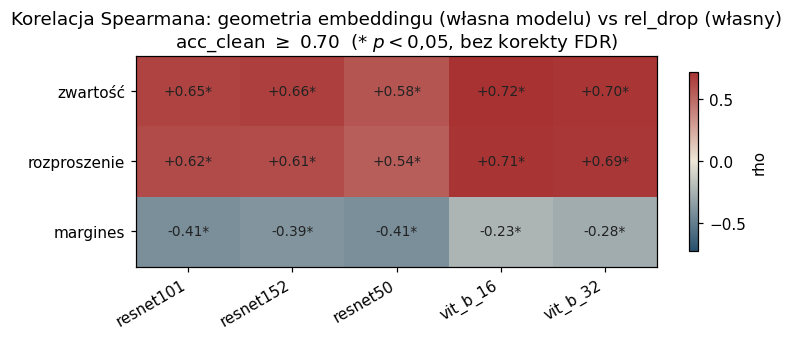

model         resnet101  resnet152  resnet50  vit_b_16  vit_b_32
cecha                                                           
zwartość          0.650      0.658     0.578     0.720     0.699
rozproszenie      0.616      0.610     0.543     0.708     0.694
margines         -0.412     -0.387    -0.415    -0.234    -0.280


In [ ]:
heat = []
for m in MODELS:
    sub = (CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)][['wnid', 'rel_drop']]
           .merge(class_repr[class_repr.model == m], on='wnid')
           .dropna(subset=REPR_FEATS + ['rel_drop']))
    for f in REPR_FEATS:
        rho, p = spearmanr(sub[f], sub['rel_drop'])
        heat.append((REPR_PL[f], m, rho, p))

H = (pd.DataFrame(heat, columns=['cecha', 'model', 'rho', 'p'])
     .pivot(index='cecha', columns='model', values='rho')
     .reindex([REPR_PL[f] for f in REPR_FEATS])[MODELS])
P = (pd.DataFrame(heat, columns=['cecha', 'model', 'rho', 'p'])
     .pivot(index='cecha', columns='model', values='p')
     .reindex([REPR_PL[f] for f in REPR_FEATS])[MODELS])

div_cmap = LinearSegmentedColormap.from_list('rho', [ROBUST_C, '#EDE7D7', FRAGILE_C])
fig, ax = plt.subplots(figsize=(1.0 * len(MODELS) + 2.2, 0.6 * len(REPR_FEATS) + 1.4))
vmax = float(np.nanmax(np.abs(H.values)))
im = ax.imshow(H.values, cmap=div_cmap, vmin=-vmax, vmax=vmax, aspect='auto')
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        rho = H.values[i, j]; pv = P.values[i, j]; star = '*' if pv < 0.05 else ''
        ax.text(j, i, f'{rho:+.2f}{star}', ha='center', va='center', fontsize=9, color='#222')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=30, ha='right')
ax.set_yticks(range(len(REPR_FEATS))); ax.set_yticklabels([REPR_PL[f] for f in REPR_FEATS])
ax.set_title(f'Korelacja Spearmana: geometria embeddingu (własna modelu) vs rel_drop (własny)\n'
             f'acc_clean $\\geq$ {MIN_CLEAN_ROBUST:.2f}  (* $p<0{{,}}05$, bez korekty FDR)')
plt.colorbar(im, ax=ax, label='rho', shrink=0.85)
plt.tight_layout(); save_fig(fig, '04c_embedding_geometry_spearman'); plt.show()

print(H.round(3).to_string())

In [ ]:
pvals = [p for (_, _, _, p) in heat]
labels = [(f, m) for (f, m, _, _) in heat]

reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

n_sig_before = sum(p < 0.05 for p in pvals)
n_sig_after = sum(reject)
print(f'Istotne przed korekta FDR: {n_sig_before}/{len(pvals)}')
print(f'Istotne po korekcie FDR:   {n_sig_after}/{len(pvals)}')

if n_sig_after < len(pvals):
    print('\nTe, ktore stracily istotnosc:')
    for (f, m), p, r in zip(labels, pvals_corrected, reject):
        if not r:
            print(f'  {f} / {m}: p_skorygowane = {p:.4f}')
else:
    print('\nWszystkie 15 pozostaje istotne po korekcie FDR.')

Istotne przed korekta FDR: 15/15
Istotne po korekcie FDR:   15/15

Wszystkie 15 pozostaje istotne po korekcie FDR.


## 7. Łączna siła predykcyjna geometrii (las losowy)

In [ ]:
cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for m in MODELS:
    sub = (CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)][['wnid', 'rel_drop']]
           .merge(class_repr[class_repr.model == m], on='wnid')
           .dropna(subset=REPR_FEATS + ['rel_drop']))
    Xr = sub[REPR_FEATS].values
    yr = sub['rel_drop'].values
    try:
        r2 = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42),
                              Xr, yr, cv=cv_shuffled, scoring='r2').mean()
    except Exception:
        r2 = float('nan')
    rows.append((m, len(sub), r2))
    print(f'{m:<12} n={len(sub):<4} R2_CV (geometria embeddingu, cv tasowane) = {r2:+.3f}')

r2_tab = pd.DataFrame(rows, columns=['model', 'n_klas', 'r2_cv'])
r2_tab.to_csv(f'{ANALYSIS_DIR}/embedding_geometry_rf_r2.csv', index=False)
print(f'\nDla porównania (populacja inna, bez filtra acc_clean, cv niepewne wobec tasowania): '
      f'cechy obrazu (6d.4) R2_CV = -0.10')

resnet101    n=820  R2_CV (geometria embeddingu, cv tasowane) = +0.325
resnet152    n=835  R2_CV (geometria embeddingu, cv tasowane) = +0.394
resnet50     n=794  R2_CV (geometria embeddingu, cv tasowane) = +0.346
vit_b_16     n=813  R2_CV (geometria embeddingu, cv tasowane) = +0.486
vit_b_32     n=706  R2_CV (geometria embeddingu, cv tasowane) = +0.428

Dla porównania (populacja inna, bez filtra acc_clean, cv niepewne wobec tasowania): cechy obrazu (6d.4) R2_CV = -0.10


## 8. Profil geometrii: klasy wspólnie podatne vs wspólnie odporne, porównanie geometrii reprezentacji klas wspólnie podatnych i odpornych

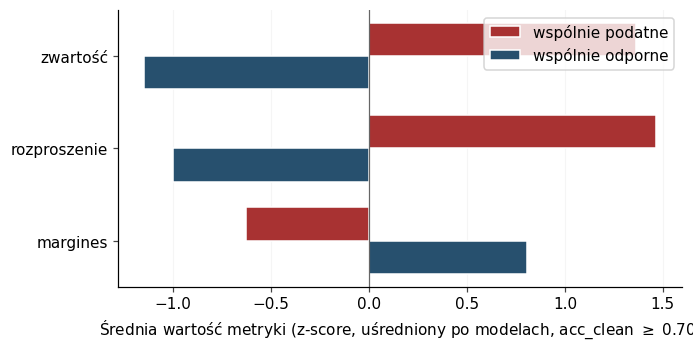

                  compactness  dispersion  margin
kind                                             
pozostałe               0.144       0.110  -0.137
wspólnie odporne       -1.150      -1.001   0.807
wspólnie podatne        1.363       1.467  -0.630


In [ ]:
zf_parts = []
for m in MODELS:
    sub = (class_repr[class_repr.model == m][['wnid'] + REPR_FEATS]
           .merge(CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)][['wnid']], on='wnid'))
    for f in REPR_FEATS:
        sub[f] = (sub[f] - sub[f].mean()) / (sub[f].std() + 1e-9)
    zf_parts.append(sub)

zf = (pd.concat(zf_parts, ignore_index=True)
        .groupby('wnid')[REPR_FEATS].mean()
        .reset_index())

zf['kind'] = np.where(zf.wnid.isin(shared_fragile), 'wspólnie podatne',
              np.where(zf.wnid.isin(shared_robust),  'wspólnie odporne', 'pozostałe'))

KIND_COLORS = {'wspólnie podatne': FRAGILE_C, 'wspólnie odporne': ROBUST_C, 'pozostałe': OTHER_C}

mean_fr = zf[zf.kind == 'wspólnie podatne'][REPR_FEATS].mean()
mean_ro = zf[zf.kind == 'wspólnie odporne'][REPR_FEATS].mean()

order = (mean_fr - mean_ro).abs().sort_values(ascending=True).index.tolist()
ypos = np.arange(len(order)); barh = 0.36
fig, ax = plt.subplots(figsize=(6.4, 0.7 * len(order) + 1.2))
ax.barh(ypos + barh / 2, [mean_fr[f] for f in order], height=barh,
        color=FRAGILE_C, edgecolor='white', label='wspólnie podatne', zorder=2)
ax.barh(ypos - barh / 2, [mean_ro[f] for f in order], height=barh,
        color=ROBUST_C, edgecolor='white', label='wspólnie odporne', zorder=2)
ax.axvline(0, color='#666', lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels([REPR_PL[f] for f in order])
ax.set_xlabel('Średnia wartość metryki (z-score, uśredniony po modelach, acc_clean $\\geq$ '
              f'{MIN_CLEAN_ROBUST:.2f})')
ax.legend(loc='best'); ax.grid(axis='x', alpha=0.12); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_embedding_geometry_fragile_vs_robust'); plt.show()

print(zf.groupby('kind')[REPR_FEATS].mean().round(3).to_string())

## 9. Zapisane artefakty

Tabele w `analysis/`, wykresy w `figures/` (pliki `04c_*`), surowe embeddingi w `embeddings/`.

In [ ]:
print('Tabele (analysis/):')
for f in sorted(os.listdir(ANALYSIS_DIR)):
    if 'embedding' in f or 'geometry' in f:
        print('  ', f, f'({os.path.getsize(os.path.join(ANALYSIS_DIR, f)) / 1024:.1f} KB)')

print('\nFigury (figures/04c_*):')
for f in sorted(os.listdir(FIGURES_DIR)):
    if f.startswith('04c_'):
        print('  ', f)

print('\nCache embeddingów (embeddings/):')
for f in sorted(os.listdir(EMB_DIR)):
    print('  ', f, f'({os.path.getsize(os.path.join(EMB_DIR, f)) / 1024 / 1024:.1f} MB)')


Tabele (analysis/):
   class_embedding_drift.csv (229.9 KB)
   class_embedding_drift_resnet101.csv (46.6 KB)
   class_embedding_drift_resnet152.csv (46.7 KB)
   class_embedding_drift_resnet50.csv (45.6 KB)
   class_embedding_drift_vit_b_16.csv (45.5 KB)
   class_embedding_drift_vit_b_32.csv (45.6 KB)
   class_embedding_geometry.csv (396.8 KB)
   embedding_geometry_floor_check.csv (1.2 KB)
   embedding_geometry_rf_r2.csv (0.2 KB)

Figury (figures/04c_*):
   04c_drift_by_category.pdf
   04c_drift_by_category.png
   04c_drift_by_category_resnet50.pdf
   04c_drift_by_category_resnet50.png
   04c_drift_fragile_vs_robust_by_severity.pdf
   04c_drift_fragile_vs_robust_by_severity.png
   04c_drift_fragile_vs_robust_by_severity_resnet50.pdf
   04c_drift_fragile_vs_robust_by_severity_resnet50.png
   04c_drift_heatmap_15x5.pdf
   04c_drift_heatmap_15x5.png
   04c_drift_heatmap_15x5_resnet50.pdf
   04c_drift_heatmap_15x5_resnet50.png
   04c_drift_heatmap_15x5_vitb16.pdf
   04c_drift_heatmap_15x5_v

## 10. Dryft embeddingu pod zakłóceniem (wszystkie modele, ograniczony zakres zaklóceń)

**Zakres ograniczony celowo** (pelny 15 zaklócen x 5 severity jak w notebooku 04 byłby tu za drogi obliczeniowo):
- modele: wszystkie 5 (`DRIFT_MODELS = MODELS`)
- zaklócenia: po jednym z kazdej z 4 kategorii ImageNet-C - `gaussian_noise`, `motion_blur`, `fog`, `jpeg_compression`
- severity: 3 (srodkowa)
- 10 obrazow/klase, z tego samego zbioru "poprawnie klasyfikowanych" obrazów

In [ ]:
_imagecorruptions_dir = os.path.dirname(_ic.__file__)
_corruptions_file_path = os.path.join(_imagecorruptions_dir, 'corruptions.py')

if os.path.exists(_corruptions_file_path):
    with open(_corruptions_file_path, 'r') as f:
        _content = f.read()
    if 'np.float_' in _content:
        with open(_corruptions_file_path, 'w') as f:
            f.write(_content.replace('np.float_', 'np.float64'))
        print(f"Spatchowano '{_corruptions_file_path}' (np.float_ -> np.float64)")
        if 'imagecorruptions.corruptions' in sys.modules:
            importlib.reload(sys.modules['imagecorruptions.corruptions'])
    else:
        print(f"'{_corruptions_file_path}' juz spatchowany.")
else:
    print(f"UWAGA: '{_corruptions_file_path}' nie znaleziony, patch pominiety.")

DRIFT_MODELS      = list(MODELS)
DRIFT_CORRUPTIONS = ['gaussian_noise', 'motion_blur', 'fog', 'jpeg_compression']
DRIFT_SEVERITY    = 3
DRIFT_IMGS_PER_CLASS = 10

for m in DRIFT_MODELS:
    assert m in MODELS, f'{m} nie ma w MODELS'

Spatchowano '/usr/local/lib/python3.12/dist-packages/imagecorruptions/corruptions.py' (np.float_ -> np.float64)


### 10.1 Ekstrakcja: dryft i spillover per klasa

`mean_drift` - srednia odleglosc kosinusowa embeddingu zaklóconego obrazu od embeddingu tego samego obrazu bez zaklócenia (parami, ten sam obraz).

`spillover_rate` - odsetek zaklóconych obrazów klasy, ktorych embedding ląduje bliżej centroidu **innej** klasy (policzonego na czystych, poprawnie sklasyfikowanych obrazach) niż własnego.

In [ ]:
def _centroids_from_embeddings(emb_by_class):
    wnids = list(emb_by_class.keys())
    C = np.stack([emb_by_class[w].mean(axis=0) for w in wnids])
    Cn = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-9)
    return wnids, Cn

def build_drift_metrics(model, arch, correct_positions, centroid_wnids, centroids_n,
                         batch_size=64):
    wnid_to_row = {w: i for i, w in enumerate(centroid_wnids)}
    rows = []

    for w in tqdm(TARGET_WNIDS, desc=f'dryft {arch}'):
        idx = WNID_TO_IDX.get(w)
        all_positions = BY_CLASS.get(idx, [])
        positions = [p for p in all_positions if p in correct_positions][:DRIFT_IMGS_PER_CLASS]
        if not positions or w not in wnid_to_row:
            continue
        own_row = wnid_to_row[w]

        clean_imgs = [to_uint8_224(ds_val[int(p)]['image']) for p in positions]
        clean_tensors = torch.stack([_to_tensor(im) for im in clean_imgs]).to(DEVICE)
        clean_emb = extract_embeddings_batch(model, arch, clean_tensors)
        clean_emb_n = clean_emb / (np.linalg.norm(clean_emb, axis=1, keepdims=True) + 1e-9)

        drifts, spill_flags = [], []
        for corr_name in DRIFT_CORRUPTIONS:
            corr_imgs = []
            for im in clean_imgs:
                arr = corrupt(im, corruption_name=corr_name, severity=DRIFT_SEVERITY)
                if arr.dtype != np.uint8:
                    arr = np.clip(arr, 0, 255).astype(np.uint8)
                corr_imgs.append(arr)
            corr_tensors = torch.stack([_to_tensor(im) for im in corr_imgs]).to(DEVICE)

            corr_emb = []
            for i in range(0, len(corr_imgs), batch_size):
                corr_emb.append(extract_embeddings_batch(model, arch, corr_tensors[i:i + batch_size]))
            corr_emb = np.concatenate(corr_emb, axis=0)
            corr_emb_n = corr_emb / (np.linalg.norm(corr_emb, axis=1, keepdims=True) + 1e-9)

            # dryft: 1 - cos(embedding zaklócony, embedding czysty), parami
            d = 1 - np.sum(corr_emb_n * clean_emb_n, axis=1)
            drifts.append(d)

            # spillover: czy najblizszy centroid (ze wszystkich klas) to WLASNA klasa
            sims_to_all = corr_emb_n @ centroids_n.T
            nearest = sims_to_all.argmax(axis=1)
            spill_flags.append(nearest != own_row)

        mean_drift = float(np.mean(np.concatenate(drifts)))
        spillover_rate = float(np.mean(np.concatenate(spill_flags)))
        rows.append((w, mean_drift, spillover_rate, len(positions) * len(DRIFT_CORRUPTIONS)))

    return pd.DataFrame(rows, columns=['wnid', 'mean_drift', 'spillover_rate', 'n_par'])

In [ ]:
DRIFT_CSV = f'{ANALYSIS_DIR}/class_embedding_drift.csv'
DRIFT_PART_CACHE = {m: f'{ANALYSIS_DIR}/class_embedding_drift_{m}.csv' for m in DRIFT_MODELS}

if os.path.exists(DRIFT_CSV):
    drift_df = pd.read_csv(DRIFT_CSV)
    print(f'Wczytano dryft z cache: {DRIFT_CSV} ({len(drift_df)} wierszy)')
else:
    parts = []
    for m in DRIFT_MODELS:
        part_path = DRIFT_PART_CACHE[m]
        if os.path.exists(part_path):
            dm = pd.read_csv(part_path)
            print(f'{m}: wczytano z czesciowego cache ({part_path})')
            parts.append(dm)
            continue

        print(f'{m}: wczytuje maske poprawnosci...')
        correct_positions = load_clean_correct_positions(m)

        print(f'{m}: licze centroidy z istniejacych embeddingow (sekcja 4)...')
        centroid_wnids, centroids_n = _centroids_from_embeddings(class_embeddings[m])

        print(f'{m}: laduje model i licze dryft ({len(DRIFT_CORRUPTIONS)} zaklócen x '
              f'{DRIFT_IMGS_PER_CLASS} obrazow/klase)...')
        model = load_model(m)
        dm = build_drift_metrics(model, m, correct_positions, centroid_wnids, centroids_n)
        dm['model'] = m
        dm.to_csv(part_path, index=False)
        print(f'{m}: zapisano czesciowy cache -> {part_path}')
        parts.append(dm)
        del model
        torch.cuda.empty_cache()

    drift_df = pd.concat(parts, ignore_index=True)
    drift_df.to_csv(DRIFT_CSV, index=False)
    print(f'Zapisano polaczony wynik: {DRIFT_CSV}')

drift_df.groupby('model')[['mean_drift', 'spillover_rate']].describe().round(3)

Wczytano dryft z cache: /content/drive/MyDrive/mgr_266484/analysis/class_embedding_drift.csv (5000 wierszy)


mean_drift                                                  spillover_rate                                               
               count   mean    std    min    25%    50%    75%    max          count   mean    std  min    25%    50%    75%    max
model                                                                                                                              
resnet101     1000.0  0.292  0.060  0.124  0.252  0.292  0.332  0.484         1000.0  0.240  0.136  0.0  0.150  0.225  0.325  0.675
resnet152     1000.0  0.265  0.061  0.080  0.225  0.266  0.308  0.472         1000.0  0.209  0.126  0.0  0.125  0.200  0.275  0.700
resnet50      1000.0  0.369  0.056  0.189  0.330  0.372  0.407  0.525         1000.0  0.332  0.148  0.0  0.225  0.325  0.425  0.875
vit_b_16      1000.0  0.346  0.058  0.188  0.308  0.345  0.384  0.515         1000.0  0.197  0.125  0.0  0.100  0.175  0.275  0.725
vit_b_32      1000.0  0.328  0.056  0.170  0.290  0.328  0.366  0.517         1000.0  0.238  0.128  0.0  0.150  0.225  0.325  0.625

### 10.2 Dryft/spillover vs podatność i vs geometria bazowa

Dwa pytania:
1. Czy `mean_drift`/`spillover_rate` same w sobie koreluja z `rel_drop` (filtr `acc_clean >= MIN_CLEAN_ROBUST` jak w sekcjach 6-8)?
2. Czy dodanie ich do modelu z geometrii bazowej (`compactness`, `dispersion`, `margin`) podnosi $R^2$ ponad to, co dawala sama geometria bazowa (sekcja 7)? Analogicznie do 6f.2 w notebooku 04.

In [ ]:
for m in DRIFT_MODELS:
    sub = (CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)][['wnid', 'rel_drop']]
           .merge(drift_df[drift_df.model == m], on='wnid')
           .dropna(subset=['mean_drift', 'spillover_rate', 'rel_drop']))
    rho_d, _ = spearmanr(sub['mean_drift'], sub['rel_drop'])
    rho_s, _ = spearmanr(sub['spillover_rate'], sub['rel_drop'])
    print(f'{m:<12} n={len(sub):<4} rho(dryft, rel_drop)={rho_d:+.3f}   '
          f'rho(spillover, rel_drop)={rho_s:+.3f}')

print()
for m in DRIFT_MODELS:
    sub = (CT[(CT.model == m) & (CT.acc_clean >= MIN_CLEAN_ROBUST)][['wnid', 'rel_drop']]
           .merge(class_repr[class_repr.model == m], on='wnid')
           .merge(drift_df[drift_df.model == m][['wnid', 'mean_drift', 'spillover_rate']], on='wnid')
           .dropna(subset=REPR_FEATS + ['mean_drift', 'spillover_rate', 'rel_drop']))
    yr = sub['rel_drop'].values

    r2_base = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42),
                               sub[REPR_FEATS].values, yr, cv=cv_shuffled, scoring='r2').mean()
    r2_drift = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42),
                                sub[['mean_drift', 'spillover_rate']].values, yr,
                                cv=cv_shuffled, scoring='r2').mean()
    r2_all = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42),
                              sub[REPR_FEATS + ['mean_drift', 'spillover_rate']].values, yr,
                              cv=cv_shuffled, scoring='r2').mean()

    print(f'{m:<12} n={len(sub):<4} R2 geometria bazowa={r2_base:+.3f}   '
          f'R2 sam dryft={r2_drift:+.3f}   R2 razem={r2_all:+.3f}')

resnet101    n=820  rho(dryft, rel_drop)=+0.620   rho(spillover, rel_drop)=+0.625
resnet152    n=835  rho(dryft, rel_drop)=+0.669   rho(spillover, rel_drop)=+0.601
resnet50     n=794  rho(dryft, rel_drop)=+0.535   rho(spillover, rel_drop)=+0.629
vit_b_16     n=813  rho(dryft, rel_drop)=+0.630   rho(spillover, rel_drop)=+0.655
vit_b_32     n=706  rho(dryft, rel_drop)=+0.622   rho(spillover, rel_drop)=+0.641

resnet101    n=820  R2 geometria bazowa=+0.325   R2 sam dryft=+0.329   R2 razem=+0.564
resnet152    n=835  R2 geometria bazowa=+0.394   R2 sam dryft=+0.363   R2 razem=+0.588
resnet50     n=794  R2 geometria bazowa=+0.346   R2 sam dryft=+0.311   R2 razem=+0.582
vit_b_16     n=813  R2 geometria bazowa=+0.486   R2 sam dryft=+0.364   R2 razem=+0.666
vit_b_32     n=706  R2 geometria bazowa=+0.428   R2 sam dryft=+0.343   R2 razem=+0.629


## 11. Pelny dryft po severity, jeden model (ViT-B/16)

In [ ]:
def _fast_glass_blur(x, severity=1):
    c = [(0.7, 1, 2), (0.9, 2, 1), (1, 2, 3), (1.1, 3, 2), (1.5, 4, 2)][severity - 1]
    sigma, max_delta, n_iter = c
    arr = np.asarray(x, dtype=np.float32) / 255.0
    arr = _sk_filters.gaussian(arr, sigma=sigma, channel_axis=-1)
    arr = (arr * 255).astype(np.uint8)
    H, W = arr.shape[:2]
    rng = np.random.RandomState()
    for _ in range(n_iter):
        dy = rng.randint(-max_delta, max_delta + 1, size=(H, W))
        dx = rng.randint(-max_delta, max_delta + 1, size=(H, W))
        ii = np.clip(np.arange(H)[:, None] + dy, 0, H - 1)
        jj = np.clip(np.arange(W)[None, :] + dx, 0, W - 1)
        arr = arr[ii, jj]
    arr = _sk_filters.gaussian(arr.astype(np.float32) / 255.0, sigma=sigma, channel_axis=-1)
    return np.clip(arr * 255, 0, 255).astype(np.uint8)

if hasattr(_ic, 'corruption_dict'):
    _ic.corruption_dict['glass_blur'] = _fast_glass_blur

FULL_MODEL = 'vit_b_16'
FULL_CORRUPTIONS = ['gaussian_noise', 'shot_noise', 'impulse_noise',
                     'defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur',
                     'snow', 'frost', 'fog', 'brightness',
                     'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression']
FULL_SEVERITIES = [1, 2, 3, 4, 5]
FULL_IMGS_PER_CLASS = 10

assert FULL_MODEL in class_embeddings, (
    f'{FULL_MODEL}: brak w class_embeddings - uruchom najpierw sekcje 4 dla tego modelu.'
)

### 11.1 Cache obrazów czystych
Dekoduje obrazy z \`ds_val\` raz i trzyma w pamieci przez cala sesje - unika ponownego dekodowania tych samych 10 000 obrazow przy kazdej z 75 kombinacji. Embeddingi czyste biore z \`class_embeddings['vit_b_16']\` (juz policzone w sekcji 4), nie licze ich ponownie.

In [ ]:
correct_positions_full = load_clean_correct_positions(FULL_MODEL)
centroid_wnids_full, centroids_n_full = _centroids_from_embeddings(class_embeddings[FULL_MODEL])
wnid_to_row_full = {w: i for i, w in enumerate(centroid_wnids_full)}

clean_images_cache = {}      # wnid -> lista uint8 [224,224,3]
clean_embeddings_slice = {}  # wnid -> [n_imgs, D] znormalizowane, ten sam porzadek co obrazy

for w in tqdm(TARGET_WNIDS, desc='cache obrazow czystych'):
    idx = WNID_TO_IDX.get(w)
    positions = [p for p in BY_CLASS.get(idx, []) if p in correct_positions_full][:FULL_IMGS_PER_CLASS]
    if not positions or w not in class_embeddings[FULL_MODEL]:
        continue
    clean_images_cache[w] = [to_uint8_224(ds_val[int(p)]['image']) for p in positions]
    emb = class_embeddings[FULL_MODEL][w][:len(positions)]
    clean_embeddings_slice[w] = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)

print(f'Cache gotowy: {len(clean_images_cache)} klas.')

cache obrazow czystych:   0%|          | 0/1000 [00:00<?, ?it/s]

Cache gotowy: 1000 klas.


### 11.2 Siatka 15 x 5, zapis częściowy per kombinacja

Uruchom te komorke wielokrotnie (mozna w roznych sesjach) - kazde uruchomienie doliczy tylko brakujace kombinacje, pomijajac juz zapisane. Zeby ograniczyc jedna sesje do jednej kategorii zaklócen, przefiltruj \`FULL_CORRUPTIONS\` przed uruchomieniem, np.:
\`\`\`python
FULL_CORRUPTIONS = ['gaussian_noise', 'shot_noise', 'impulse_noise']  # tylko 'noise' w tej sesji
\`\`\`

In [ ]:
model_full = load_model(FULL_MODEL)

for corr_name in FULL_CORRUPTIONS:
    for sev in FULL_SEVERITIES:
        combo_path = f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL}_{corr_name}_sev{sev}.csv'
        if os.path.exists(combo_path):
            continue

        rows = []
        for w, clean_imgs in tqdm(clean_images_cache.items(),
                                   desc=f'{corr_name} sev={sev}', leave=False):
            clean_emb_n = clean_embeddings_slice[w]
            corr_imgs = []
            for im in clean_imgs:
                arr = corrupt(im, corruption_name=corr_name, severity=sev)
                if arr.dtype != np.uint8:
                    arr = np.clip(arr, 0, 255).astype(np.uint8)
                corr_imgs.append(arr)
            corr_tensors = torch.stack([_to_tensor(im) for im in corr_imgs]).to(DEVICE)
            corr_emb = extract_embeddings_batch(model_full, FULL_MODEL, corr_tensors)
            corr_emb_n = corr_emb / (np.linalg.norm(corr_emb, axis=1, keepdims=True) + 1e-9)

            drift = 1 - np.sum(corr_emb_n * clean_emb_n, axis=1)
            sims_to_all = corr_emb_n @ centroids_n_full.T
            nearest = sims_to_all.argmax(axis=1)
            spill = (nearest != wnid_to_row_full[w])

            rows.append((w, float(drift.mean()), float(spill.mean()), len(clean_imgs)))

        pd.DataFrame(rows, columns=['wnid', 'mean_drift', 'spillover_rate', 'n_imgs']
                     ).to_csv(combo_path, index=False)
        print(f'zapisano {combo_path}')

del model_full
torch.cuda.empty_cache()
print('\nGotowe (albo przerwane - uruchom komorke ponownie, zeby dokonczyc brakujace).')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 162MB/s]



Gotowe (albo przerwane - uruchom komorke ponownie, zeby dokonczyc brakujace).


### 11.3 Zlozenie wynikow i krzywa dryftu po severity  

Znaleziono 75 / 75 kombinacji.


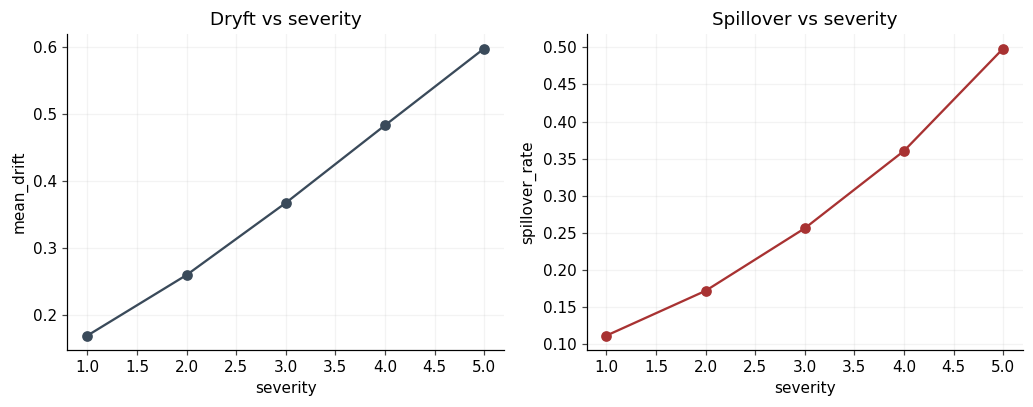

In [ ]:
combo_files = glob.glob(f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL}_*_sev*.csv')
print(f'Znaleziono {len(combo_files)} / {len(FULL_CORRUPTIONS) * len(FULL_SEVERITIES)} kombinacji.')

parts = []
for fp in combo_files:
    base = os.path.basename(fp).replace(f'drift_full_{FULL_MODEL}_', '').replace('.csv', '')
    corr_name, sev_str = base.rsplit('_sev', 1)
    d = pd.read_csv(fp)
    d['corruption'] = corr_name
    d['severity'] = int(sev_str)
    parts.append(d)

if parts:
    full_drift = pd.concat(parts, ignore_index=True)
    full_drift.to_csv(f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL}_combined.csv', index=False)

    by_sev = full_drift.groupby('severity')[['mean_drift', 'spillover_rate']].mean()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8))
    ax1.plot(by_sev.index, by_sev['mean_drift'], marker='o', color=ACCENT)
    ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft vs severity')
    ax1.grid(alpha=0.15); tidy(ax1)
    ax2.plot(by_sev.index, by_sev['spillover_rate'], marker='o', color=FRAGILE_C)
    ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Spillover vs severity')
    ax2.grid(alpha=0.15); tidy(ax2)
    plt.tight_layout(); save_fig(fig, '04c_full_drift_by_severity'); plt.show()
else:
    print('Brak policzonych kombinacji - uruchom komorke 10.2.')

In [ ]:
assert 'full_drift' in dir(), 'Brak full_drift - uruchom sekcje 10.3 (skladanie wynikow) najpierw.'

CORR_CATEGORY = {
    'gaussian_noise': 'noise', 'shot_noise': 'noise', 'impulse_noise': 'noise',
    'defocus_blur': 'blur', 'glass_blur': 'blur', 'motion_blur': 'blur', 'zoom_blur': 'blur',
    'snow': 'weather', 'frost': 'weather', 'fog': 'weather', 'brightness': 'weather',
    'contrast': 'digital', 'elastic_transform': 'digital', 'pixelate': 'digital',
    'jpeg_compression': 'digital',
}
CAT_PL_LOCAL = {'noise': 'szum', 'blur': 'rozmycie', 'weather': 'pogoda', 'digital': 'cyfrowe'}
CORR_PL_LOCAL = {c: c.replace('_', ' ') for c in FULL_CORRUPTIONS}

full_drift['category'] = full_drift['corruption'].map(CORR_CATEGORY)

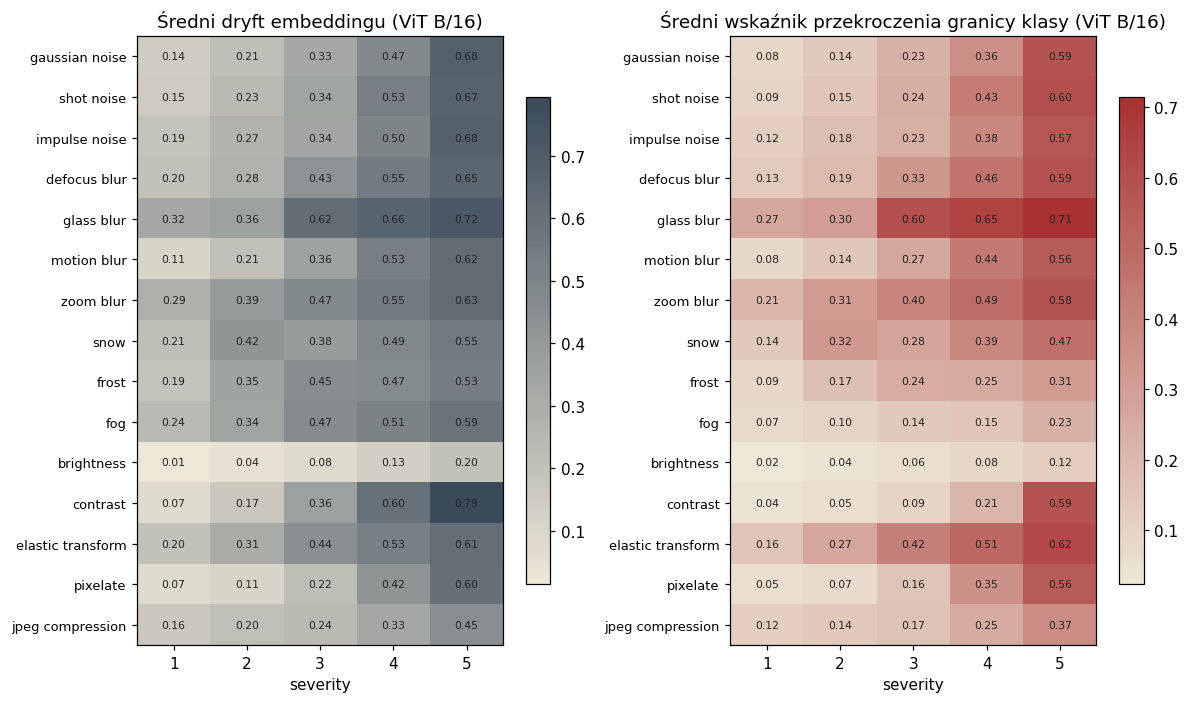

In [ ]:
agg = full_drift.groupby(['corruption', 'severity'])[['mean_drift', 'spillover_rate']].mean()

corr_order = FULL_CORRUPTIONS
H_drift = agg['mean_drift'].unstack('severity').reindex(corr_order)
H_spill = agg['spillover_rate'].unstack('severity').reindex(corr_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, H, title, cmap_colors in [
    (ax1, H_drift, 'Średni dryft embeddingu (ViT B/16)', ['#EDE7D7', ACCENT]),
    (ax2, H_spill, 'Średni wskaźnik przekroczenia granicy klasy (ViT B/16)', ['#EDE7D7', FRAGILE_C])
]:
    cmap = LinearSegmentedColormap.from_list('c', cmap_colors)
    im = ax.imshow(H.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(H.columns))); ax.set_xticklabels(H.columns)
    ax.set_yticks(range(len(H.index)))
    ax.set_yticklabels([CORR_PL_LOCAL[c] for c in H.index], fontsize=8.5)
    ax.set_xlabel('severity'); ax.set_title(title)
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v = H.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='#222')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(); save_fig(fig, '04c_drift_heatmap_15x5'); plt.show()

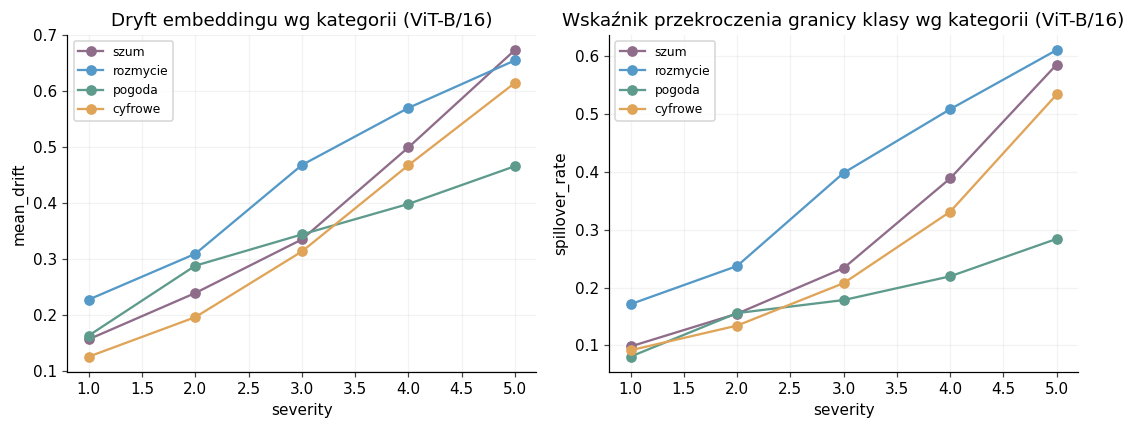

In [ ]:
by_cat = full_drift.groupby(['category', 'severity'])[['mean_drift', 'spillover_rate']].mean().reset_index()
CAT_COLORS = {'noise': '#8e6c8a', 'blur': '#5499c7', 'weather': '#5e9b8c', 'digital': '#e0a458'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for cat in ['noise', 'blur', 'weather', 'digital']:
    sub = by_cat[by_cat.category == cat].sort_values('severity')
    ax1.plot(sub.severity, sub.mean_drift, marker='o', color=CAT_COLORS[cat], label=CAT_PL_LOCAL[cat])
    ax2.plot(sub.severity, sub.spillover_rate, marker='o', color=CAT_COLORS[cat], label=CAT_PL_LOCAL[cat])

ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft embeddingu wg kategorii (ViT-B/16)')
ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Wskaźnik przekroczenia granicy klasy wg kategorii (ViT-B/16)')
for ax in (ax1, ax2):
    ax.grid(alpha=0.15); ax.legend(fontsize=8); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_drift_by_category'); plt.show()

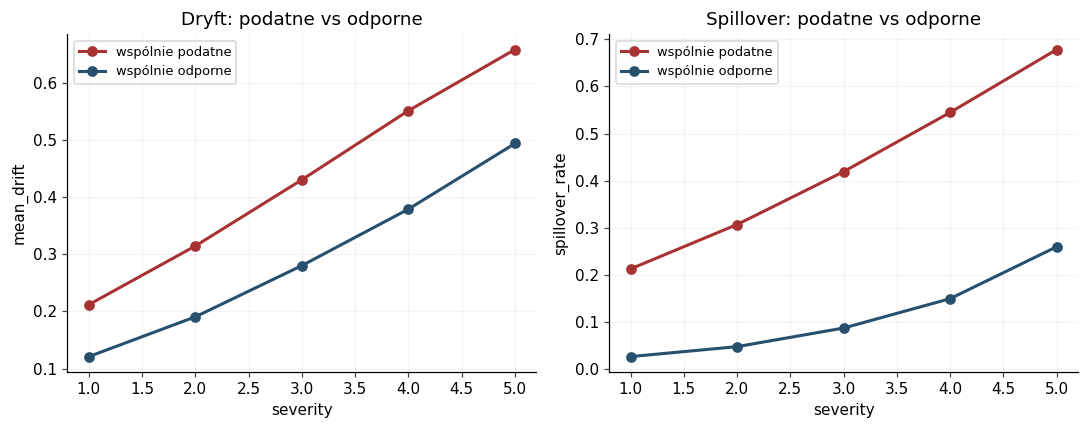

Przepasc (dryft podatne - odporne) po severity:
severity
1    0.091
2    0.124
3    0.150
4    0.172
5    0.164


In [ ]:
fd = full_drift.copy()
fd['kind'] = np.where(fd.wnid.isin(shared_fragile), 'wspólnie podatne',
              np.where(fd.wnid.isin(shared_robust),  'wspólnie odporne', 'pozostałe'))

by_kind_sev = (fd[fd.kind != 'pozostałe']
               .groupby(['kind', 'severity'])[['mean_drift', 'spillover_rate']]
               .mean().reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for kind, color in [('wspólnie podatne', FRAGILE_C), ('wspólnie odporne', ROBUST_C)]:
    sub = by_kind_sev[by_kind_sev.kind == kind].sort_values('severity')
    ax1.plot(sub.severity, sub.mean_drift, marker='o', color=color, label=kind, linewidth=2)
    ax2.plot(sub.severity, sub.spillover_rate, marker='o', color=color, label=kind, linewidth=2)

ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft: podatne vs odporne')
ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Spillover: podatne vs odporne')
for ax in (ax1, ax2):
    ax.grid(alpha=0.15); ax.legend(fontsize=8.5); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_drift_fragile_vs_robust_by_severity'); plt.show()

gap = (by_kind_sev.pivot(index='severity', columns='kind', values='mean_drift'))
gap['gap'] = gap['wspólnie podatne'] - gap['wspólnie odporne']
print('Przepasc (dryft podatne - odporne) po severity:')
print(gap['gap'].round(3).to_string())

Dopasowanych wierszy (klasa x zaklócenie x severity): 75000
rho(spillover_rate, empiryczny odsetek bledow) = +0.886  (p=0.0e+00)
rho(mean_drift, empiryczny odsetek bledow)      = +0.759  (p=0.0e+00)


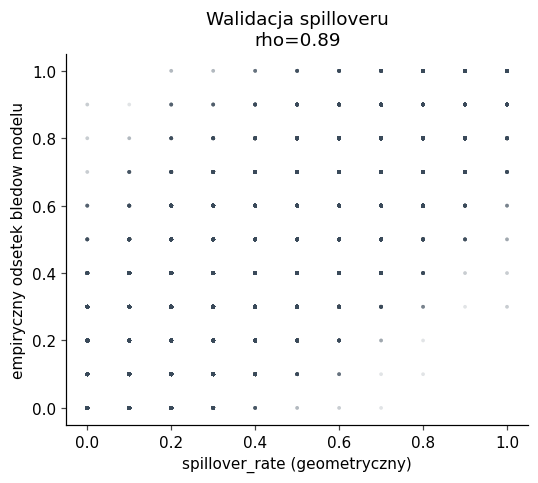

In [ ]:
pi_full = pd.read_csv(f'{RESULTS_DIR}/{FULL_MODEL}/per_image.csv')
pi_full = pi_full[pi_full.corruption.isin(FULL_CORRUPTIONS)].copy()
pi_full['pos'] = pi_full['filename'].map(_filename_to_pos)

used_positions = set()
for w, imgs in clean_images_cache.items():
    idx = WNID_TO_IDX.get(w)
    positions = [p for p in BY_CLASS.get(idx, []) if p in correct_positions_full][:FULL_IMGS_PER_CLASS]
    used_positions.update(positions)

pi_full = pi_full[pi_full.pos.isin(used_positions)]

emp_err = (pi_full.groupby(['wnid', 'corruption', 'severity'])['top1_correct']
           .agg(lambda s: 1 - s.mean()).reset_index()
           .rename(columns={'top1_correct': 'empirical_error_rate'}))

valid = full_drift.merge(emp_err, on=['wnid', 'corruption', 'severity'], how='inner')
print(f'Dopasowanych wierszy (klasa x zaklócenie x severity): {len(valid)}')

rho_spill, p_spill = spearmanr(valid['spillover_rate'], valid['empirical_error_rate'])
rho_drift, p_drift = spearmanr(valid['mean_drift'], valid['empirical_error_rate'])
print(f'rho(spillover_rate, empiryczny odsetek bledow) = {rho_spill:+.3f}  (p={p_spill:.1e})')
print(f'rho(mean_drift, empiryczny odsetek bledow)      = {rho_drift:+.3f}  (p={p_drift:.1e})')

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(valid['spillover_rate'], valid['empirical_error_rate'],
           s=6, alpha=0.15, color=ACCENT, edgecolor='none')
ax.set_xlabel('spillover_rate (geometryczny)')
ax.set_ylabel('empiryczny odsetek bledow modelu')
ax.set_title(f'Walidacja spilloveru\nrho={rho_spill:.2f}')
tidy(ax); plt.tight_layout(); save_fig(fig, '04c_spillover_validation'); plt.show()

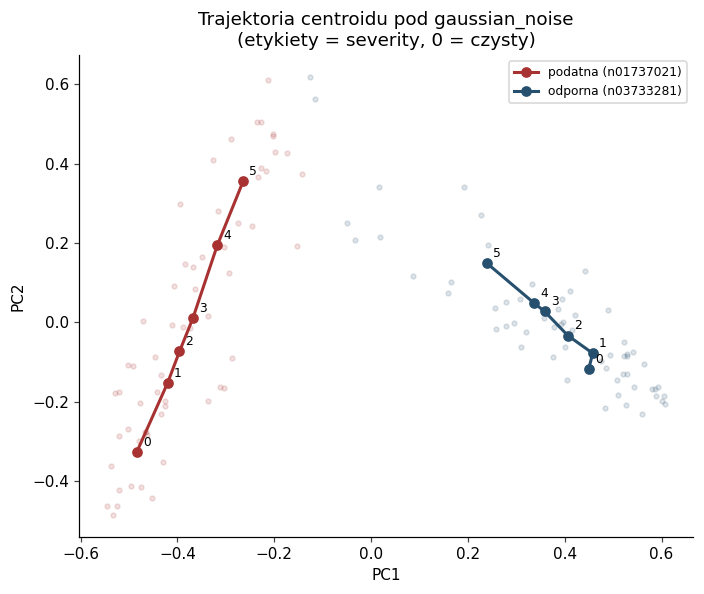

In [ ]:
candidates_fragile = [w for w in shared_fragile if w in clean_images_cache]
candidates_robust  = [w for w in shared_robust  if w in clean_images_cache]
assert candidates_fragile and candidates_robust, 'Brak kandydatow w cache - sprawdz sekcje 10.1'

example_fragile = candidates_fragile[0]
example_robust  = candidates_robust[0]
example_corr = 'gaussian_noise'

model_ex = load_model(FULL_MODEL)

traj_points, traj_labels, traj_sev, traj_class = [], [], [], []
for wnid, kind in [(example_fragile, 'podatna'), (example_robust, 'odporna')]:
    clean_imgs = clean_images_cache[wnid]
    clean_emb_n = clean_embeddings_slice[wnid]
    traj_points.append(clean_emb_n)
    traj_labels += [f'{kind} (severity 0)'] * len(clean_imgs)
    traj_sev += [0] * len(clean_imgs)
    traj_class += [kind] * len(clean_imgs)

    for sev in FULL_SEVERITIES:
        corr_imgs = [corrupt(im, corruption_name=example_corr, severity=sev) for im in clean_imgs]
        corr_tensors = torch.stack([_to_tensor(im) for im in corr_imgs]).to(DEVICE)
        corr_emb = extract_embeddings_batch(model_ex, FULL_MODEL, corr_tensors)
        corr_emb_n = corr_emb / (np.linalg.norm(corr_emb, axis=1, keepdims=True) + 1e-9)
        traj_points.append(corr_emb_n)
        traj_labels += [f'{kind} (severity {sev})'] * len(clean_imgs)
        traj_sev += [sev] * len(clean_imgs)
        traj_class += [kind] * len(clean_imgs)

del model_ex; torch.cuda.empty_cache()

X = np.concatenate(traj_points, axis=0)
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

df_traj = pd.DataFrame({'pc1': X2[:, 0], 'pc2': X2[:, 1], 'severity': traj_sev, 'kind': traj_class})
centroids_traj = df_traj.groupby(['kind', 'severity'])[['pc1', 'pc2']].mean().reset_index()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for kind, color in [('podatna', FRAGILE_C), ('odporna', ROBUST_C)]:
    sub = df_traj[df_traj.kind == kind]
    ax.scatter(sub.pc1, sub.pc2, s=10, alpha=0.15, color=color)
    ctr = centroids_traj[centroids_traj.kind == kind].sort_values('severity')
    ax.plot(ctr.pc1, ctr.pc2, marker='o', color=color, linewidth=2,
            label=f'{kind} ({example_fragile if kind == "podatna" else example_robust})')
    for _, row in ctr.iterrows():
        ax.annotate(str(int(row.severity)), (row.pc1, row.pc2), fontsize=8,
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Trajektoria centroidu pod {example_corr}\n(etykiety = severity, 0 = czysty)')
ax.legend(fontsize=8); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_pca_trajectory_example'); plt.show()

## 12. Pelny dryft po severity, drugi model (ResNet-50)  

In [ ]:
FULL_MODEL_R50 = 'resnet50'

assert FULL_MODEL_R50 in class_embeddings, (
    f'{FULL_MODEL_R50}: brak w class_embeddings - uruchom najpierw sekcje 4 dla tego modelu.'
)

print(f'Model: {FULL_MODEL_R50}')
print(f'Zaklocenia: {len(FULL_CORRUPTIONS)}, severity: {FULL_SEVERITIES}, obrazy/klase: {FULL_IMGS_PER_CLASS}')

Model: resnet50
Zaklocenia: 15, severity: [1, 2, 3, 4, 5], obrazy/klase: 10


### 12.1 Cache obrazow czystych (ResNet-50)

In [ ]:
correct_positions_r50 = load_clean_correct_positions(FULL_MODEL_R50)
centroid_wnids_r50, centroids_n_r50 = _centroids_from_embeddings(class_embeddings[FULL_MODEL_R50])
wnid_to_row_r50 = {w: i for i, w in enumerate(centroid_wnids_r50)}

clean_images_cache_r50 = {}
clean_embeddings_slice_r50 = {}

for w in tqdm(TARGET_WNIDS, desc='cache obrazow czystych (resnet50)'):
    idx = WNID_TO_IDX.get(w)
    positions = [p for p in BY_CLASS.get(idx, []) if p in correct_positions_r50][:FULL_IMGS_PER_CLASS]
    if not positions or w not in class_embeddings[FULL_MODEL_R50]:
        continue
    clean_images_cache_r50[w] = [to_uint8_224(ds_val[int(p)]['image']) for p in positions]
    emb = class_embeddings[FULL_MODEL_R50][w][:len(positions)]
    clean_embeddings_slice_r50[w] = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)

print(f'Cache gotowy: {len(clean_images_cache_r50)} klas.')

cache obrazow czystych (resnet50):   0%|          | 0/1000 [00:00<?, ?it/s]

Cache gotowy: 1000 klas.


### 12.2 Siatka 15 x 5, zapis częściowy per kombinacja (ResNet-50)

In [ ]:
model_r50 = load_model(FULL_MODEL_R50)

for corr_name in FULL_CORRUPTIONS:
    for sev in FULL_SEVERITIES:
        combo_path = f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL_R50}_{corr_name}_sev{sev}.csv'
        if os.path.exists(combo_path):
            continue

        rows = []
        for w, clean_imgs in tqdm(clean_images_cache_r50.items(),
                                   desc=f'{corr_name} sev={sev} (resnet50)', leave=False):
            clean_emb_n = clean_embeddings_slice_r50[w]
            corr_imgs = []
            for im in clean_imgs:
                arr = corrupt(im, corruption_name=corr_name, severity=sev)
                if arr.dtype != np.uint8:
                    arr = np.clip(arr, 0, 255).astype(np.uint8)
                corr_imgs.append(arr)
            corr_tensors = torch.stack([_to_tensor(im) for im in corr_imgs]).to(DEVICE)
            corr_emb = extract_embeddings_batch(model_r50, FULL_MODEL_R50, corr_tensors)
            corr_emb_n = corr_emb / (np.linalg.norm(corr_emb, axis=1, keepdims=True) + 1e-9)

            drift = 1 - np.sum(corr_emb_n * clean_emb_n, axis=1)
            sims_to_all = corr_emb_n @ centroids_n_r50.T
            nearest = sims_to_all.argmax(axis=1)
            spill = (nearest != wnid_to_row_r50[w])

            rows.append((w, float(drift.mean()), float(spill.mean()), len(clean_imgs)))

        pd.DataFrame(rows, columns=['wnid', 'mean_drift', 'spillover_rate', 'n_imgs']
                     ).to_csv(combo_path, index=False)
        print(f'zapisano {combo_path}')

del model_r50
torch.cuda.empty_cache()
print('\nGotowe (albo przerwane -   uruchom komorke ponownie, zeby dokonczyc brakujace).')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:05<00:00, 19.6MB/s]



Gotowe (albo przerwane -   uruchom komorke ponownie, zeby dokonczyc brakujace).


### 12.3 Złożenie wyników i krzywa dryftu po severity (ResNet-50)

Znaleziono 75 / 75 kombinacji.


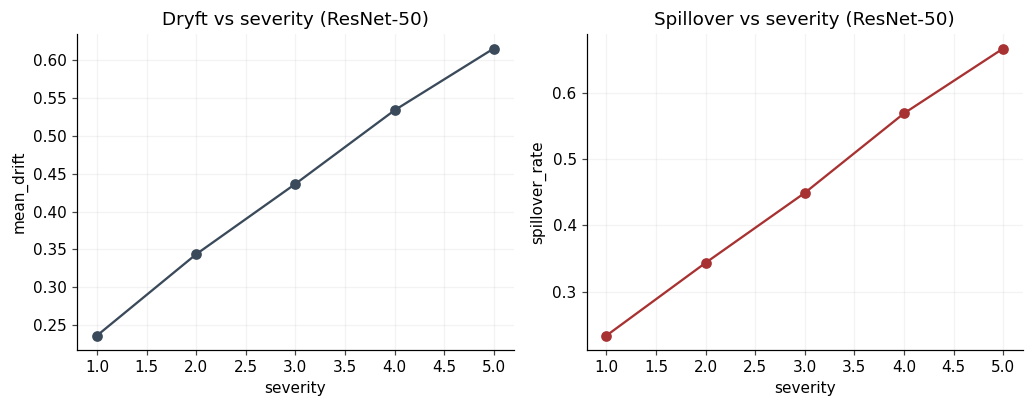

In [ ]:
combo_files_r50 = glob.glob(f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL_R50}_*_sev*.csv')
print(f'Znaleziono {len(combo_files_r50)} / {len(FULL_CORRUPTIONS) * len(FULL_SEVERITIES)} kombinacji.')

parts = []
for fp in combo_files_r50:
    base = os.path.basename(fp).replace(f'drift_full_{FULL_MODEL_R50}_', '').replace('.csv', '')
    corr_name, sev_str = base.rsplit('_sev', 1)
    d = pd.read_csv(fp)
    d['corruption'] = corr_name
    d['severity'] = int(sev_str)
    parts.append(d)

if parts:
    full_drift_r50 = pd.concat(parts, ignore_index=True)
    full_drift_r50.to_csv(f'{ANALYSIS_DIR}/drift_full_{FULL_MODEL_R50}_combined.csv', index=False)

    by_sev_r50 = full_drift_r50.groupby('severity')[['mean_drift', 'spillover_rate']].mean()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8))
    ax1.plot(by_sev_r50.index, by_sev_r50['mean_drift'], marker='o', color=ACCENT)
    ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft vs severity (ResNet-50)')
    ax1.grid(alpha=0.15); tidy(ax1)
    ax2.plot(by_sev_r50.index, by_sev_r50['spillover_rate'], marker='o', color=FRAGILE_C)
    ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Spillover vs severity (ResNet-50)')
    ax2.grid(alpha=0.15); tidy(ax2)
    plt.tight_layout(); save_fig(fig, '04c_full_drift_by_severity_resnet50'); plt.show()
else:
    print('Brak policzonych kombinacji - uruchom komorke 12.2.')

In [ ]:
assert 'full_drift_r50' in dir(), 'Brak full_drift_r50 - uruchom sekcje 12.3 (skladanie wynikow) najpierw.'
assert 'CORR_CATEGORY' in dir(), 'Brak CORR_CATEGORY - uruchom najpierw komorke 11 (definicje kategorii).'

full_drift_r50['category'] = full_drift_r50['corruption'].map(CORR_CATEGORY)

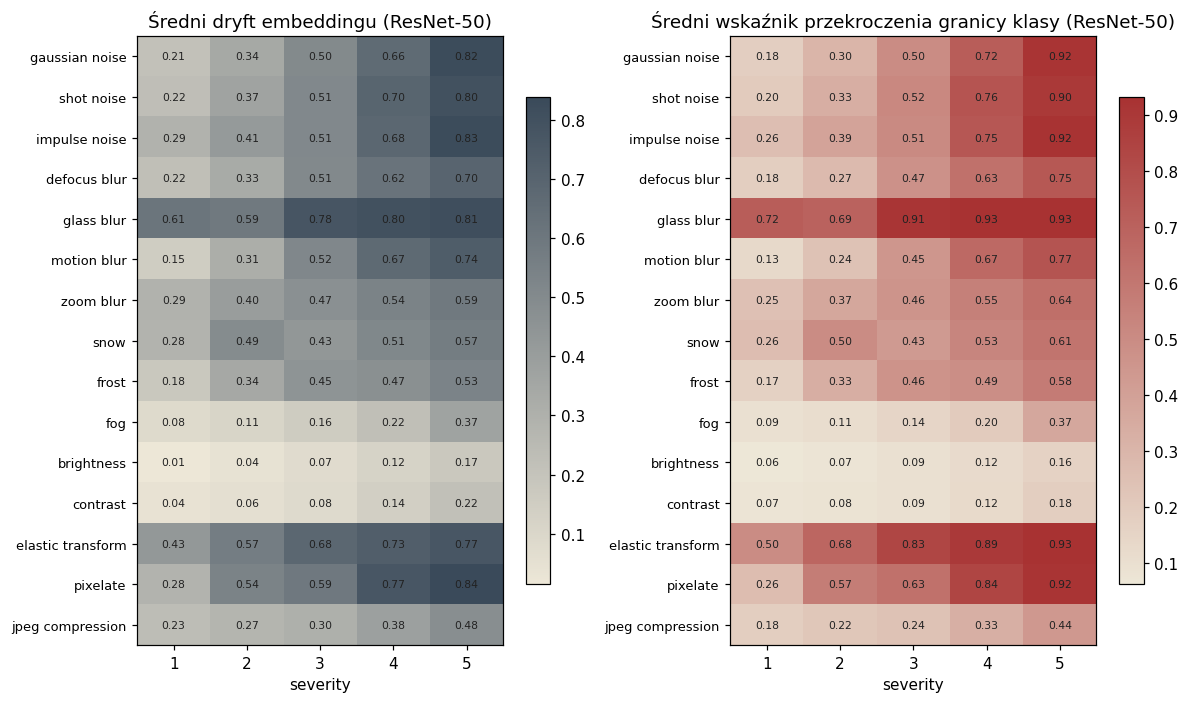

In [ ]:
agg_r50 = full_drift_r50.groupby(['corruption', 'severity'])[['mean_drift', 'spillover_rate']].mean()

corr_order = FULL_CORRUPTIONS
H_drift_r50 = agg_r50['mean_drift'].unstack('severity').reindex(corr_order)
H_spill_r50 = agg_r50['spillover_rate'].unstack('severity').reindex(corr_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, H, title, cmap_colors in [
    (ax1, H_drift_r50, 'Średni dryft embeddingu (ResNet-50)', ['#EDE7D7', ACCENT]),
    (ax2, H_spill_r50, 'Średni wskaźnik przekroczenia granicy klasy (ResNet-50)', ['#EDE7D7', FRAGILE_C])
]:
    cmap = LinearSegmentedColormap.from_list('c', cmap_colors)
    im = ax.imshow(H.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(H.columns))); ax.set_xticklabels(H.columns)
    ax.set_yticks(range(len(H.index)))
    ax.set_yticklabels([CORR_PL_LOCAL[c] for c in H.index], fontsize=8.5)
    ax.set_xlabel('severity'); ax.set_title(title)
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v = H.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='#222')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(); save_fig(fig, '04c_drift_heatmap_15x5_resnet50'); plt.show()

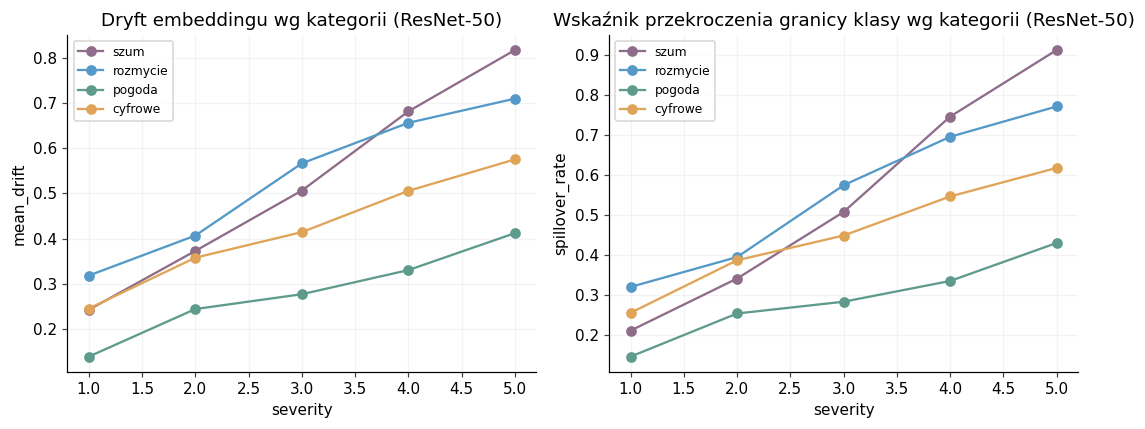

In [ ]:
by_cat_r50 = full_drift_r50.groupby(['category', 'severity'])[['mean_drift', 'spillover_rate']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for cat in ['noise', 'blur', 'weather', 'digital']:
    sub = by_cat_r50[by_cat_r50.category == cat].sort_values('severity')
    ax1.plot(sub.severity, sub.mean_drift, marker='o', color=CAT_COLORS[cat], label=CAT_PL_LOCAL[cat])
    ax2.plot(sub.severity, sub.spillover_rate, marker='o', color=CAT_COLORS[cat], label=CAT_PL_LOCAL[cat])

ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft embeddingu wg kategorii (ResNet-50)')
ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Wskaźnik przekroczenia granicy klasy wg kategorii (ResNet-50)')
for ax in (ax1, ax2):
    ax.grid(alpha=0.15); ax.legend(fontsize=8); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_drift_by_category_resnet50'); plt.show()

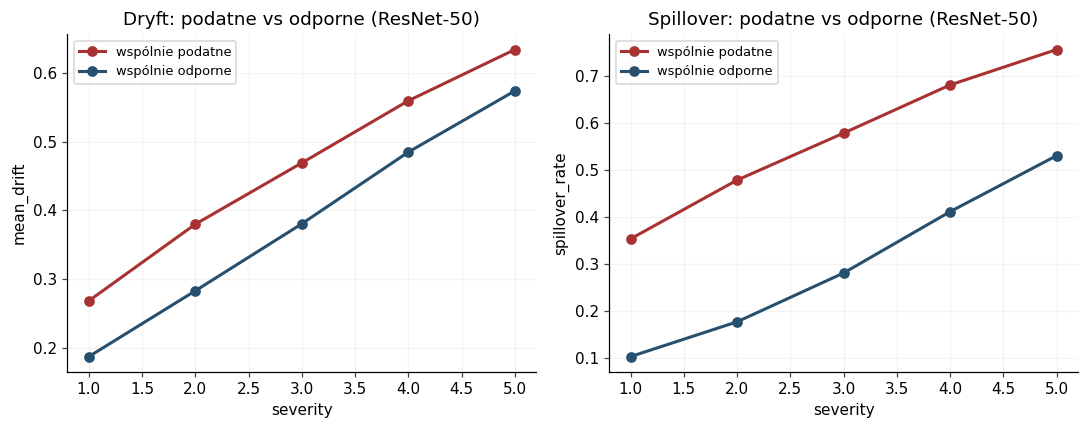

Przepasc (dryft podatne - odporne) po severity (ResNet-50):
severity
1    0.081
2    0.097
3    0.089
4    0.075
5    0.060


In [ ]:
fd_r50 = full_drift_r50.copy()
fd_r50['kind'] = np.where(fd_r50.wnid.isin(shared_fragile), 'wspólnie podatne',
                  np.where(fd_r50.wnid.isin(shared_robust),  'wspólnie odporne', 'pozostałe'))

by_kind_sev_r50 = (fd_r50[fd_r50.kind != 'pozostałe']
                   .groupby(['kind', 'severity'])[['mean_drift', 'spillover_rate']]
                   .mean().reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for kind, color in [('wspólnie podatne', FRAGILE_C), ('wspólnie odporne', ROBUST_C)]:
    sub = by_kind_sev_r50[by_kind_sev_r50.kind == kind].sort_values('severity')
    ax1.plot(sub.severity, sub.mean_drift, marker='o', color=color, label=kind, linewidth=2)
    ax2.plot(sub.severity, sub.spillover_rate, marker='o', color=color, label=kind, linewidth=2)

ax1.set_xlabel('severity'); ax1.set_ylabel('mean_drift'); ax1.set_title('Dryft: podatne vs odporne (ResNet-50)')
ax2.set_xlabel('severity'); ax2.set_ylabel('spillover_rate'); ax2.set_title('Spillover: podatne vs odporne (ResNet-50)')
for ax in (ax1, ax2):
    ax.grid(alpha=0.15); ax.legend(fontsize=8.5); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_drift_fragile_vs_robust_by_severity_resnet50'); plt.show()

gap_r50 = (by_kind_sev_r50.pivot(index='severity', columns='kind', values='mean_drift'))
gap_r50['gap'] = gap_r50['wspólnie podatne'] - gap_r50['wspólnie odporne']
print('Przepasc (dryft podatne - odporne) po severity (ResNet-50):')
print(gap_r50['gap'].round(3).to_string())

Dopasowanych wierszy (klasa x zaklócenie x severity), ResNet-50: 75000
rho(spillover_rate, empiryczny odsetek bledow) = +0.902  (p=0.0e+00)
rho(mean_drift, empiryczny odsetek bledow)      = +0.878  (p=0.0e+00)


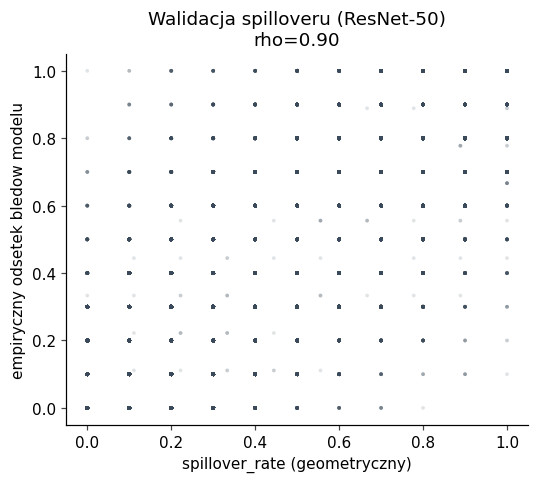

In [ ]:
pi_full_r50 = pd.read_csv(f'{RESULTS_DIR}/{FULL_MODEL_R50}/per_image.csv')
pi_full_r50 = pi_full_r50[pi_full_r50.corruption.isin(FULL_CORRUPTIONS)].copy()
pi_full_r50['pos'] = pi_full_r50['filename'].map(_filename_to_pos)

used_positions_r50 = set()
for w, imgs in clean_images_cache_r50.items():
    idx = WNID_TO_IDX.get(w)
    positions = [p for p in BY_CLASS.get(idx, []) if p in correct_positions_r50][:FULL_IMGS_PER_CLASS]
    used_positions_r50.update(positions)

pi_full_r50 = pi_full_r50[pi_full_r50.pos.isin(used_positions_r50)]

emp_err_r50 = (pi_full_r50.groupby(['wnid', 'corruption', 'severity'])['top1_correct']
               .agg(lambda s: 1 - s.mean()).reset_index()
               .rename(columns={'top1_correct': 'empirical_error_rate'}))

valid_r50 = full_drift_r50.merge(emp_err_r50, on=['wnid', 'corruption', 'severity'], how='inner')
print(f'Dopasowanych wierszy (klasa x zaklócenie x severity), ResNet-50: {len(valid_r50)}')

rho_spill_r50, p_spill_r50 = spearmanr(valid_r50['spillover_rate'], valid_r50['empirical_error_rate'])
rho_drift_r50, p_drift_r50 = spearmanr(valid_r50['mean_drift'], valid_r50['empirical_error_rate'])
print(f'rho(spillover_rate, empiryczny odsetek bledow) = {rho_spill_r50:+.3f}  (p={p_spill_r50:.1e})')
print(f'rho(mean_drift, empiryczny odsetek bledow)      = {rho_drift_r50:+.3f}  (p={p_drift_r50:.1e})')

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(valid_r50['spillover_rate'], valid_r50['empirical_error_rate'],
           s=6, alpha=0.15, color=ACCENT, edgecolor='none')
ax.set_xlabel('spillover_rate (geometryczny)')
ax.set_ylabel('empiryczny odsetek bledow modelu')
ax.set_title(f'Walidacja spilloveru (ResNet-50)\nrho={rho_spill_r50:.2f}')
tidy(ax); plt.tight_layout(); save_fig(fig, '04c_spillover_validation_resnet50'); plt.show()

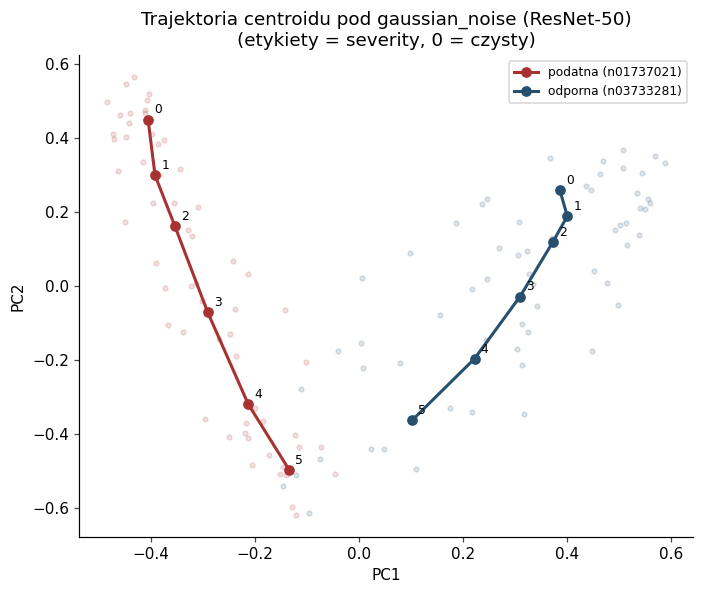

In [ ]:
candidates_fragile_r50 = [w for w in shared_fragile if w in clean_images_cache_r50]
candidates_robust_r50  = [w for w in shared_robust  if w in clean_images_cache_r50]
assert candidates_fragile_r50 and candidates_robust_r50, 'Brak kandydatow w cache - sprawdz sekcje 12.1'

example_fragile_r50 = candidates_fragile_r50[0]
example_robust_r50  = candidates_robust_r50[0]
example_corr_r50 = 'gaussian_noise'

model_ex_r50 = load_model(FULL_MODEL_R50)

traj_points_r50, traj_labels_r50, traj_sev_r50, traj_class_r50 = [], [], [], []
for wnid, kind in [(example_fragile_r50, 'podatna'), (example_robust_r50, 'odporna')]:
    clean_imgs = clean_images_cache_r50[wnid]
    clean_emb_n = clean_embeddings_slice_r50[wnid]
    traj_points_r50.append(clean_emb_n)
    traj_labels_r50 += [f'{kind} (severity 0)'] * len(clean_imgs)
    traj_sev_r50 += [0] * len(clean_imgs)
    traj_class_r50 += [kind] * len(clean_imgs)

    for sev in FULL_SEVERITIES:
        corr_imgs = [corrupt(im, corruption_name=example_corr_r50, severity=sev) for im in clean_imgs]
        corr_tensors = torch.stack([_to_tensor(im) for im in corr_imgs]).to(DEVICE)
        corr_emb = extract_embeddings_batch(model_ex_r50, FULL_MODEL_R50, corr_tensors)
        corr_emb_n = corr_emb / (np.linalg.norm(corr_emb, axis=1, keepdims=True) + 1e-9)
        traj_points_r50.append(corr_emb_n)
        traj_labels_r50 += [f'{kind} (severity {sev})'] * len(clean_imgs)
        traj_sev_r50 += [sev] * len(clean_imgs)
        traj_class_r50 += [kind] * len(clean_imgs)

del model_ex_r50; torch.cuda.empty_cache()

X_r50 = np.concatenate(traj_points_r50, axis=0)
pca_r50 = PCA(n_components=2, random_state=42)
X2_r50 = pca_r50.fit_transform(X_r50)

df_traj_r50 = pd.DataFrame({'pc1': X2_r50[:, 0], 'pc2': X2_r50[:, 1], 'severity': traj_sev_r50, 'kind': traj_class_r50})
centroids_traj_r50 = df_traj_r50.groupby(['kind', 'severity'])[['pc1', 'pc2']].mean().reset_index()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for kind, color in [('podatna', FRAGILE_C), ('odporna', ROBUST_C)]:
    sub = df_traj_r50[df_traj_r50.kind == kind]
    ax.scatter(sub.pc1, sub.pc2, s=10, alpha=0.15, color=color)
    ctr = centroids_traj_r50[centroids_traj_r50.kind == kind].sort_values('severity')
    ax.plot(ctr.pc1, ctr.pc2, marker='o', color=color, linewidth=2,
            label=f'{kind} ({example_fragile_r50 if kind == "podatna" else example_robust_r50})')
    for _, row in ctr.iterrows():
        ax.annotate(str(int(row.severity)), (row.pc1, row.pc2), fontsize=8,
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Trajektoria centroidu pod {example_corr_r50} (ResNet-50)\n(etykiety = severity, 0 = czysty)')
ax.legend(fontsize=8); tidy(ax)
plt.tight_layout(); save_fig(fig, '04c_pca_trajectory_example_resnet50'); plt.show()